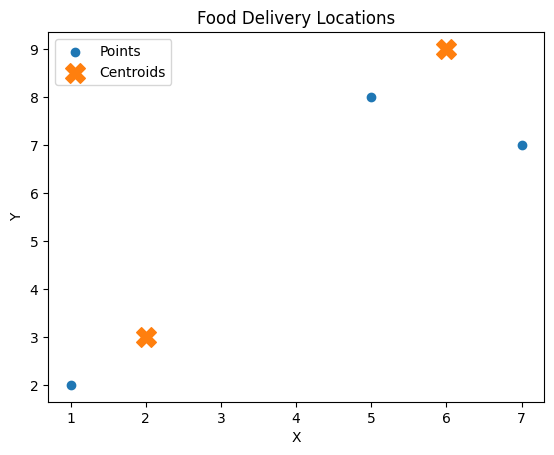

In [1]:
# Given a small dataset of 2D points representing food delivery locations (e.g., [2,3], [5,8], [1,2], [6,9], [7,7]),
# plot the points on graph paper or using matplotlib, randomly pick two initial centroids,
# and manually assign each point to the nearest centroid using Euclidean distance.

import matplotlib.pyplot as plt

points = [(2,3), (5,8), (1,2), (6,9), (7,7)]
centroids = [(2,3), (6,9)]

x = [p[0] for p in points]
y = [p[1] for p in points]

plt.scatter(x, y, label='Points')
plt.scatter(
    [c[0] for c in centroids],
    [c[1] for c in centroids],
    marker='X',
    s=200,
    label='Centroids'
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Food Delivery Locations")
plt.legend()
plt.show()

In [2]:
# Write a Python function assign_clusters(points, centroids) that takes a list of points
# and a list of centroids, and returns a list showing which cluster each point belongs to using Euclidean distance.

import math

def assign_clusters(points, centroids):
    assignments = []

    for point in points:
        distances = []

        for centroid in centroids:
            distance = math.sqrt(
                (point[0] - centroid[0])**2 +
                (point[1] - centroid[1])**2
            )
            distances.append(distance)

        assignments.append(distances.index(min(distances)))

    return assignments


# Example
points = [(2,3), (5,8), (1,2), (6,9), (7,7)]
centroids = [(2,3), (6,9)]

print(assign_clusters(points, centroids))

[0, 1, 0, 1, 1]


In [3]:
# 3. Update your assign_clusters code to work with Manhattan distance as well.
# Allow the user to choose between 'euclidean' and 'manhattan' as a parameter.

def assign_clusters(points, centroids, metric='euclidean'):
    assignments = []

    for point in points:
        distances = []

        for centroid in centroids:

            if metric == 'euclidean':
                distance = math.sqrt(
                    (point[0]-centroid[0])**2 +
                    (point[1]-centroid[1])**2
                )

            elif metric == 'manhattan':
                distance = (
                    abs(point[0]-centroid[0]) +
                    abs(point[1]-centroid[1])
                )

            else:
                raise ValueError(
                    "Metric must be 'euclidean' or 'manhattan'"
                )

            distances.append(distance)

        assignments.append(distances.index(min(distances)))

    return assignments


# Example
print(assign_clusters(points, centroids, 'euclidean'))
print(assign_clusters(points, centroids, 'manhattan'))

[0, 1, 0, 1, 1]
[0, 1, 0, 1, 1]


In [4]:
# Implement a function update_centroids(points, assignments, k) that calculates the new centroid
# for each cluster as the mean of the assigned points. Test it with a sample dataset of your choice.

def update_centroids(points, assignments, k):
    new_centroids = []
    for cluster in range(k):

        cluster_points = [
            points[i]
            for i in range(len(points))
            if assignments[i] == cluster
        ]

        if len(cluster_points) == 0:
            centroids.append((0,0))
            continue

        mean_x = sum(p[0] for p in cluster_points) / len(cluster_points)
        mean_y = sum(p[1] for p in cluster_points) / len(cluster_points)

        centroids.append((mean_x, mean_y))

    return centroids


# Sample Test

points = [(2,3), (5,8), (1,2), (6,9), (7,7)]
assignments = [0,1,0,1,1]

new_centroids = update_centroids(points, assignments, 2)

print(new_centroids)

[(2, 3), (6, 9), (1.5, 2.5), (6.0, 8.0)]


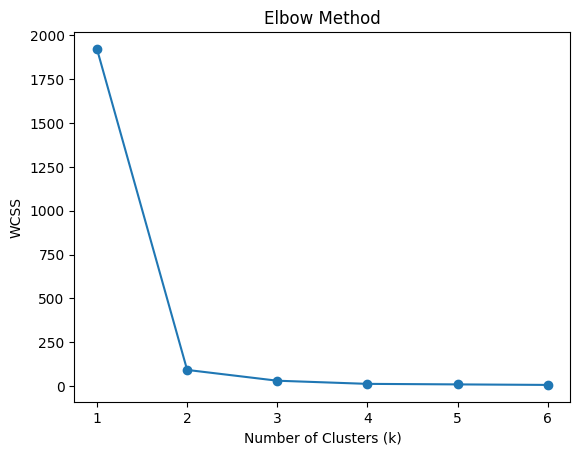

In [5]:
# Use the Elbow Method to determine the optimal number of clusters (k) for a dataset of your choice
# (e.g., favorite songs by tempo and danceability, or Zomato restaurant ratings and price).
# Plot the within-cluster sum of squares for k=1 to k=6 and identify the 'elbow' point.
# <br><br><em><strong>Hint:</strong> Use sklearn's KMeans and matplotlib for plotting.</em>

data = [
    [2,3],
    [1,2],
    [3,4],
    [5,8],
    [6,9],
    [7,7],
    [20,25],
    [22,24],
    [23,27],
    [25,28]
]

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

data = [
    [2,3],
    [1,2],
    [3,4],
    [5,8],
    [6,9],
    [7,7],
    [20,25],
    [22,24],
    [23,27],
    [25,28]
]

wcss = []

for k in range(1, 7):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(data)

    wcss.append(kmeans.inertia_)

plt.plot(range(1,7), wcss, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()